In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from concurrent.futures import ThreadPoolExecutor


In [2]:
# FULLY AUTONOMOUS EXTRACTION NODES

# 1. Applying Contour Fourier Descriptors to get Macro-Shape
def cfd(img):
    """
    Isolates the shape and converts the boundary into a frequency signal.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea) if contours else None
    
    if contour is None:
        return np.zeros(32).tolist()
    
    # 1D Fast Fourier Transform on the boundary coordinates
    comp_contour = contour[:, 0, 0] + 1j * contour[:, 0, 1]
    fourier_ = np.fft.fft(comp_contour)
    
    # Extract magnitude (skipping the 0th DC component)
    mag = np.abs(fourier_)[1:33]
    
    if len(mag) < 32:
        mag = np.pad(mag, (0, 32 - len(mag)))
        
    return mag.tolist()

# 2. Applying Hu Moments to get Internal Geometry
def hum(img):
    """
    Calculates the statistical center of mass and pixel weight distribution.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY) # Check the difference in results
    
    # Calculate Hu Moments
    moments = cv2.moments(mask)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Logarithmic transform to compress mathematical variance
    hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    
    return hu_log.tolist()

# 3. Applying HSV Histogram to get Color Palette
def hsv(img):
    """
    Maps the material composition and paint of the sprite.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Calculate 3D histogram strictly within the masked body
    hist = cv2.calcHist([img_hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    
    return hist.flatten().tolist()

# 4. Applying Local Binary Patterns to get Micro-Texture
def lbp(img):
    """
    Scans 3x3 pixel grids to capture surface roughness and shading edges.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    
    radius = 1
    n_points = 8 * radius
    
    # Compute LBP and isolate the object's body
    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    lbp_masked = lbp[mask > 0]
    
    # Build translation-invariant histogram
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins))
    
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)
    
    return hist.tolist()

In [3]:
def process_single_image(file_info):
    """
    Runs sequentially on a single core, but we will spin up 8 of these
    functions in parallel at the dataset level.
    """
    file_path, filename, category, sub_category = file_info
    img = cv2.imread(file_path)
    if img is None: return None

    # Execute the 4 blocks
    cfd_vector = cfd(img)
    hum_vector = hum(img)
    hsv_vector = hsv(img)
    lbp_vector = lbp(img)

    return {
        'image_name': filename,
        'category': category,
        'sub_category': sub_category,
        'f1_cfd': cfd_vector,
        'f2_geom': hum_vector,
        'f3_hist': hsv_vector,
        'f4_lbp': lbp_vector
    }

# The main loop that gathers the dataset
def build_multithreaded_dataset(base_dir):
    """
    The Master Controller: Gathers the files and pushes them through the CPU pipeline.
    """
    folders = ['lizard', 'orc', 'halfling', 'wingedrat', 'human']
    jobs = []
    
    print("Scanning directory tree for assets...")
    for category in folders:
        folder_path = os.path.join(base_dir, category)
        if not os.path.exists(folder_path): continue

        for filename in os.listdir(folder_path):
            if not filename.endswith(('.png', '.jpg')): continue
            file_path = os.path.join(folder_path, filename)
            
            # Extract labels purely from filename
            asset_class_type = filename.split('_')[-1][0]
            sub_category = f"{category}_{asset_class_type}"
            
            # Bundle the data needed for extraction
            jobs.append((file_path, filename, category, sub_category))

    print(f"Igniting ThreadPoolExecutor for {len(jobs)} images...")
    
    # BOTTLENECK FIX: One master thread pool running across the whole dataset
    data = []
    # Using max_workers=8 to maximize your CPU cores
    with ThreadPoolExecutor(max_workers=8) as executor:
        # map() applies the function to every item in the jobs list concurrently
        results = list(tqdm(executor.map(process_single_image, jobs), total=len(jobs)))
        
    # Filter out any unreadable images/None types
    for res in results:
        if res is not None:
            data.append(res)
            
    print(f"Extraction complete. {len(data)} assets processed.")
    return pd.DataFrame(data)

In [4]:
def optimize_gmm(x_data, min_k, max_k):
    """Finds the best K using BIC (and logs AIC)."""
    best_bic = np.inf
    best_k = min_k
    best_pred = None
    
    for k in range(min_k, max_k + 1):
        if k >= len(x_data): break 
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=47)
        gmm.fit(x_data)
        
        bic = gmm.bic(x_data)
        
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_pred = gmm.predict(x_data)
            
    return best_k, best_pred


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

def run_quad_pipeline(df):
    """Executes Block-wise PCA and a Single-Stage Bottom-Up GMM."""
    print("Running Block-wise PCA...")
    
    def compress(col):
        X = np.stack(df[col].values)
        X_scaled = StandardScaler().fit_transform(X)
        return PCA(n_components=0.95, random_state=47).fit_transform(X_scaled)

    pca_cfd = compress('f1_cfd')
    pca_geom = compress('f2_geom')
    pca_hist = compress('f3_hist')
    pca_lbp = compress('f4_lbp')
    
    fused_features = [np.concatenate((pca_cfd[i], pca_geom[i], pca_hist[i], pca_lbp[i])) for i in range(len(df))]
    X_fused = np.stack(fused_features)
    
    # ==========================================
    # STAGE 1: THE BOTTOM-UP GMM 
    # ==========================================
    # Dynamically find the target k based on actual sub-categories
    actual_k = df['sub_category'].nunique()
    min_k = actual_k - 25
    max_k = actual_k + 25
    
    print(f"\nExecuting Single-Stage GMM...")
    print(f"Targeting {actual_k} known sprite sheets. Searching k from {min_k} to {max_k}...")
    
    best_k, pred_sub = optimize_gmm(X_fused, min_k=min_k, max_k=max_k)
    df['raw_pred_sub_category'] = pred_sub
    print(f"GMM settled on {best_k} optimal micro-clusters!")

    # ==========================================
    # STAGE 2: THE MACRO ROLL-UP
    # ==========================================
    print("Rolling up Micro-Clusters into Macro-Categories...")
    df['pred_category'] = "Unassigned"
    
    for cluster_id in df['raw_pred_sub_category'].unique():
        # Look at what is inside this specific GMM bucket
        cluster_contents = df[df['raw_pred_sub_category'] == cluster_id]
        
        # What is the most common actual folder in this bucket?
        winning_macro = cluster_contents['category'].mode()[0]
        
        # Assign that folder name to the entire bucket
        df.loc[df['raw_pred_sub_category'] == cluster_id, 'pred_category'] = winning_macro

    final_cols = ['image_name', 'category', 'sub_category', 'pred_category', 'raw_pred_sub_category']
    return df[final_cols]

Scanning directory tree for assets...
Igniting ThreadPoolExecutor for 8018 images...


100%|██████████| 8018/8018 [00:25<00:00, 310.78it/s]


Extraction complete. 8018 assets processed.
Running Block-wise PCA...

Executing Single-Stage GMM...
Targeting 51 known sprite sheets. Searching k from 26 to 76...
GMM settled on 29 optimal micro-clusters!
Rolling up Micro-Clusters into Macro-Categories...

 BENCHMARK 1: MICRO-CLUSTER PURITY REPORT
Cluster [  0] | Total Images:  859 | Purity:  34.58% | Dominant Sheet: 'lizard_F' (297/859)
Cluster [  1] | Total Images:  291 | Purity:  79.73% | Dominant Sheet: 'human_C' (232/291)
Cluster [  2] | Total Images:  505 | Purity:  34.26% | Dominant Sheet: 'orc_F' (173/505)
Cluster [  3] | Total Images:  236 | Purity:  87.29% | Dominant Sheet: 'orc_M' (206/236)
Cluster [  4] | Total Images:  354 | Purity: 100.00% | Dominant Sheet: 'human_O' (354/354)
Cluster [  5] | Total Images:  633 | Purity:  48.82% | Dominant Sheet: 'lizard_E' (309/633)
Cluster [  6] | Total Images:  285 | Purity: 100.00% | Dominant Sheet: 'wingedrat_A' (285/285)
Cluster [  7] | Total Images:  354 | Purity: 100.00% | Domina

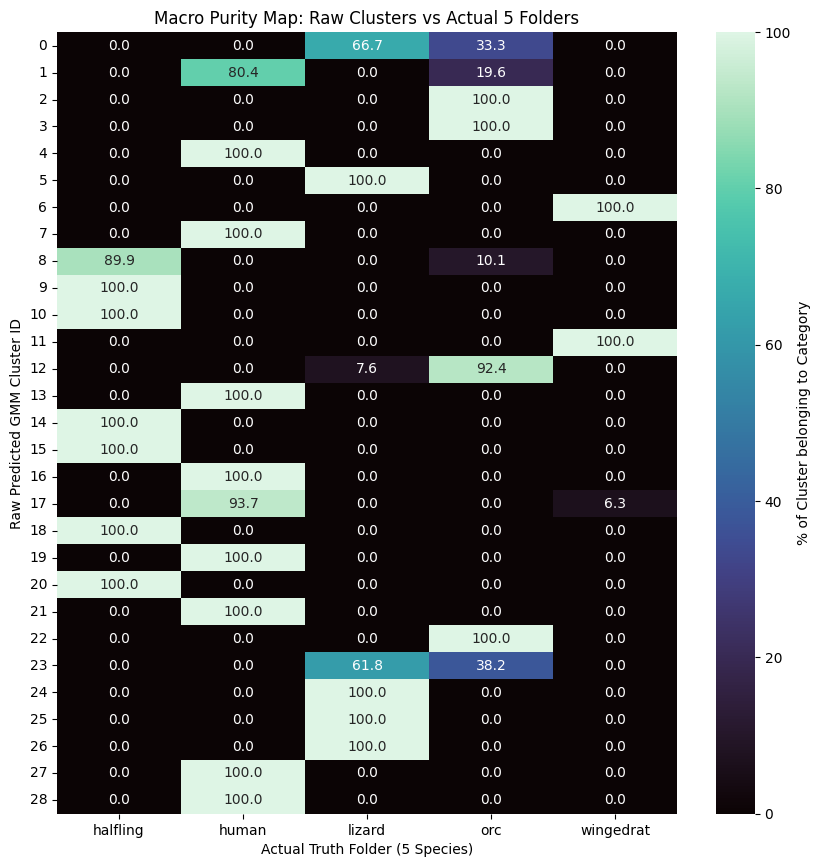

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_bottom_up_pipeline(df):
    """Evaluates Micro-Cluster Purity and generates a Row-Normalized Purity Map."""
    
    print("\n" + "="*70)
    print(" BENCHMARK 1: MICRO-CLUSTER PURITY REPORT")
    print("="*70)
    
    clusters = sorted(df['raw_pred_sub_category'].unique())
    total_pure_clusters = 0
    
    for cid in clusters:
        # Get all images that the GMM put into this specific cluster
        subset = df[df['raw_pred_sub_category'] == cid]
        total_in_cluster = len(subset)
        
        # Find the true sprite sheet that dominates this cluster
        top_sheet = subset['sub_category'].mode()[0]
        top_sheet_count = len(subset[subset['sub_category'] == top_sheet])
        
        # Calculate Purity
        purity = (top_sheet_count / total_in_cluster) * 100
        
        if purity == 100.0:
            total_pure_clusters += 1
            
        # The formatted output now explicitly states the Total Images classified into this cluster
        print(f"Cluster [{cid:>3}] | Total Images: {total_in_cluster:>4} | Purity: {purity:>6.2f}% | Dominant Sheet: '{top_sheet}' ({top_sheet_count}/{total_in_cluster})")

    print(f"\n>>> PERFECT CLUSTERS: {total_pure_clusters} out of {len(clusters)} achieved 100% Micro-Purity.")

    print("\n" + "="*70)
    print(" BENCHMARK 2: MACRO TRUTH VS. RAW PREDICTION (HEATMAP)")
    print("="*70)
    
    # Create the crosstab: Y-axis = Raw Clusters, X-axis = 5 True Folders
    # normalize='index' ensures every row adds up to 100%
    cluster_vs_macro = pd.crosstab(df['raw_pred_sub_category'], df['category'], normalize='index') * 100
    
    # Dynamically scale the height of the image based on how many clusters the GMM found
    fig_height = max(8, len(cluster_vs_macro) * 0.35)
    
    plt.figure(figsize=(10, fig_height))
    sns.heatmap(cluster_vs_macro, annot=True, fmt='.1f', cmap='mako', 
                cbar_kws={'label': '% of Cluster belonging to Category'})
    
    plt.title('Macro Purity Map: Raw Clusters vs Actual 5 Folders')
    plt.ylabel('Raw Predicted GMM Cluster ID')
    plt.xlabel('Actual Truth Folder (5 Species)')
    plt.yticks(rotation=0)
    
    # Save it in high resolution in case it's a very tall image
    plt.savefig('cluster_purity_map.png', bbox_inches='tight', dpi=150)
    plt.show()

# --- MASTER EXECUTION ---
if __name__ == "__main__":
    BASE_DIR = "./dungeon_images_colour80" 
    
    # 1. Multi-threaded Extraction
    raw_df = build_multithreaded_dataset(BASE_DIR)
    
    # 2. Mathematical Pipeline (Single-Stage Bottom-Up GMM)
    final_df = run_quad_pipeline(raw_df)
    
    # 3. Strict Purity Evaluation
    evaluate_bottom_up_pipeline(final_df)

---
## CAE

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import cv2

class SpriteCAE(nn.Module):
    def __init__(self, latent_dim=128, channels=3, img_size=64):
        super(SpriteCAE, self).__init__()
        
        self.img_size = img_size
        # Calculate the spatial size after 2 pooling layers (img_size / 4)
        self.conv_out_size = img_size // 4 
        
        # --- THE ENCODER (Compressor) ---
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * self.conv_out_size * self.conv_out_size, latent_dim)
        )
        
        # --- THE DECODER (Reconstructor) ---
        self.decoder_linear = nn.Sequential(
            nn.Linear(latent_dim, 64 * self.conv_out_size * self.conv_out_size),
            nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Forces pixel values between 0 and 1
        )

    def get_latent_features(self, x):
        """This is the crucial function: We only want the 128D fingerprint."""
        with torch.no_grad():
            return self.encoder(x)

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_linear(latent)
        x = x.view(-1, 64, self.conv_out_size, self.conv_out_size) 
        reconstruction = self.decoder_conv(x)
        return reconstruction
    
def extract_deep_features(df, base_dir, epochs=20, batch_size=64, img_size=64):
    print("Preparing Image Tensors for Deep Learning...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    # --- THE BULLETPROOF FIX ---
    print("Mapping all file paths to bypass folder structures...")
    path_map = {}
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            # Create a dictionary mapping: "lizard_A001.png" -> "./full/path/to/lizard_A001.png"
            path_map[file] = os.path.join(root, file)

    # 1. Load images using the absolute map
    images = []
    for _, row in df.iterrows():
        img_name = row['image_name']
        path = path_map.get(img_name)
        
        if path is None:
            raise FileNotFoundError(f"CRITICAL: '{img_name}' is nowhere to be found inside {base_dir}!")
            
        img = cv2.imread(path)
        
        if img is None:
            raise ValueError(f"CRITICAL: OpenCV could not read {path}. The file might be corrupted.")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        # PyTorch expects (Channels, Height, Width)
        img = np.transpose(img, (2, 0, 1)).astype(np.float32) / 255.0
        images.append(img)
        
    X_tensor = torch.tensor(np.array(images)).to(device)
    dataset = TensorDataset(X_tensor, X_tensor) 
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # 2. Initialize Model
    model = SpriteCAE(latent_dim=128, channels=3, img_size=img_size).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 3. Train the Autoencoder
    print(f"Training Convolutional Autoencoder for {epochs} epochs...")
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_features, _ in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_features)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss/len(dataloader):.4f}")

    # 4. Extract Latent Features
    print("\nExtracting 128D Latent Fingerprints...")
    model.eval()
    extract_loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=False)
    all_latents = []
    
    for batch in extract_loader:
        batch_data = batch[0]
        latent_vectors = model.get_latent_features(batch_data)
        all_latents.append(latent_vectors.cpu().numpy())
        
    fused_deep_features = np.vstack(all_latents)
    
    print("Extraction Complete!")
    return fused_deep_features

In [8]:
import umap
import hdbscan
import pandas as pd
import numpy as np

def run_deep_pipeline(df, latent_features):
    """Executes UMAP reduction and Single-Stage HDBSCAN clustering."""
    print("Crushing 128D Deep Features with UMAP...")
    
    # 1. UMAP pushes similar sprites into incredibly tight clusters
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.01, n_components=3, random_state=47)
    umap_embeddings = reducer.fit_transform(latent_features)
    
    # 2. HDBSCAN finds the natural Micro-Clusters (The individual sprite sheets)
    print("Sweeping for dense islands with HDBSCAN...")
    # min_cluster_size is the minimum number of frames required to call it a "Sprite Sheet"
    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, cluster_selection_epsilon=0.5)
    
    # We directly assign the HDBSCAN output to the sub_category
    df['raw_pred_sub_category'] = clusterer.fit_predict(umap_embeddings)
    
    total_islands = len(df['raw_pred_sub_category'].unique()) - (1 if -1 in df['raw_pred_sub_category'].values else 0)
    print(f"HDBSCAN found {total_islands} distinct sprite islands (Micro-clusters)!")
    print(f"Noise detected (Unclustered sprites): {(df['raw_pred_sub_category'] == -1).sum()}")

    # 3. The "Roll-Up" (Assigning Macro Labels)
    print("Rolling up Micro-Clusters into Macro-Categories...")
    df['pred_category'] = "Unassigned"
    
    # We map each HDBSCAN island to the 5 human folders based on what's inside it
    for cluster_id in df['raw_pred_sub_category'].unique():
        if cluster_id == -1:
            df.loc[df['raw_pred_sub_category'] == -1, 'pred_category'] = "Noise"
            continue
            
        # Look at what is inside this specific island
        island_contents = df[df['raw_pred_sub_category'] == cluster_id]
        
        # What is the most common actual folder in this island?
        winning_macro = island_contents['category'].mode()[0]
        
        # Assign that folder name to the entire island
        df.loc[df['raw_pred_sub_category'] == cluster_id, 'pred_category'] = winning_macro

    final_cols = ['image_name', 'category', 'sub_category', 'pred_category', 'raw_pred_sub_category']
    return df[final_cols]

Scanning directory tree for assets...
Igniting ThreadPoolExecutor for 8018 images...


100%|██████████| 8018/8018 [00:21<00:00, 368.70it/s]


Extraction complete. 8018 assets processed.
Preparing Image Tensors for Deep Learning...
Executing on: cuda
Mapping all file paths to bypass folder structures...
Training Convolutional Autoencoder for 20 epochs...
Epoch [1/20] | Loss: 0.0266
Epoch [5/20] | Loss: 0.0042
Epoch [10/20] | Loss: 0.0027
Epoch [15/20] | Loss: 0.0021
Epoch [20/20] | Loss: 0.0018

Extracting 128D Latent Fingerprints...
Extraction Complete!
Crushing 128D Deep Features with UMAP...


/workspace/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sweeping for dense islands with HDBSCAN...
HDBSCAN found 31 distinct sprite islands (Micro-clusters)!
Noise detected (Unclustered sprites): 3
Rolling up Micro-Clusters into Macro-Categories...

 BENCHMARK 1: MICRO-CLUSTER PURITY REPORT
Cluster [ -1] | Total Images:    3 | Purity:  66.67% | Dominant Sheet: 'orc_L' (2/3)
Cluster [  0] | Total Images:   47 | Purity: 100.00% | Dominant Sheet: 'human_P' (47/47)
Cluster [  1] | Total Images:  163 | Purity: 100.00% | Dominant Sheet: 'human_P' (163/163)
Cluster [  2] | Total Images:   27 | Purity:  25.93% | Dominant Sheet: 'human_M' (7/27)
Cluster [  3] | Total Images:  325 | Purity:  49.85% | Dominant Sheet: 'human_O' (162/325)
Cluster [  4] | Total Images:   70 | Purity:  94.29% | Dominant Sheet: 'lizard_C' (66/70)
Cluster [  5] | Total Images:  130 | Purity:  94.62% | Dominant Sheet: 'lizard_C' (123/130)
Cluster [  6] | Total Images:  158 | Purity:  97.47% | Dominant Sheet: 'halfling_A' (154/158)
Cluster [  7] | Total Images:   76 | Purity:

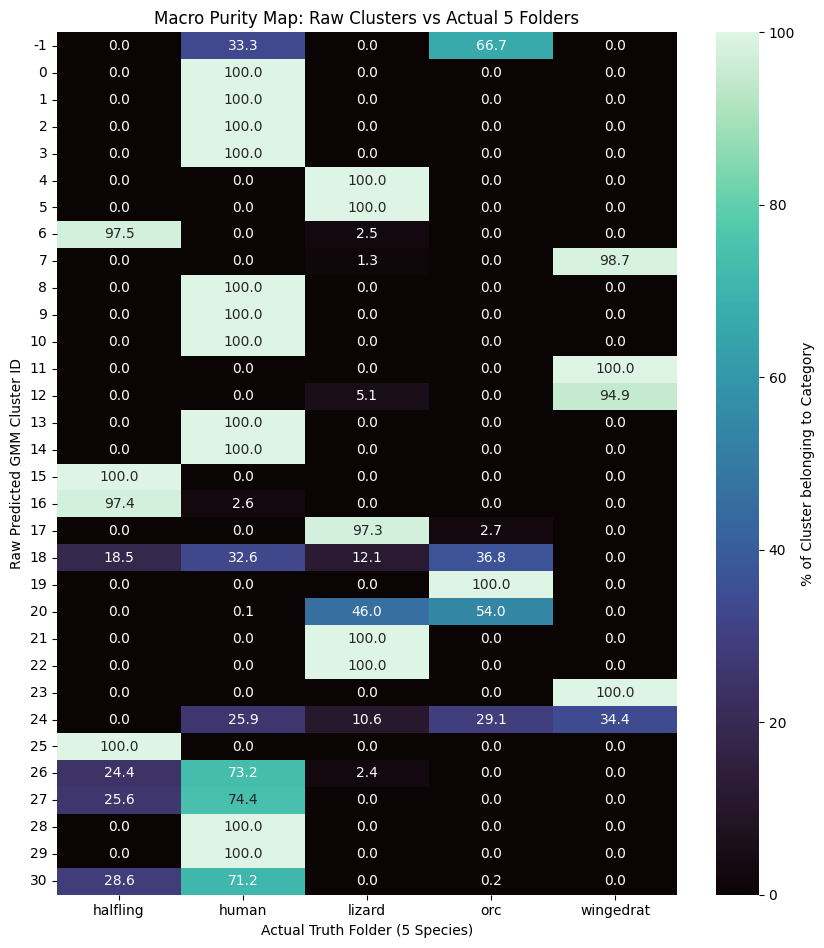

In [9]:
# --- MASTER EXECUTION ---
if __name__ == "__main__":
    BASE_DIR = "./dungeon_images_colour80" 
    
    # 1. Load Images (From your multithreaded builder)
    raw_df = build_multithreaded_dataset(BASE_DIR)
    
    # 2. Phase 1: Deep Feature Extraction (PyTorch CAE)
    # FIX: Passed BASE_DIR into the function call to satisfy the signature
    latent_vectors = extract_deep_features(raw_df, BASE_DIR, epochs=20, batch_size=64, img_size=64)
    
    # 3. Phase 2: UMAP & HDBSCAN Clustering
    final_df = run_deep_pipeline(raw_df, latent_vectors)
    
    # 4. Phase 3: Strict Evaluation 
    evaluate_bottom_up_pipeline(final_df)